In [3]:
# Part 2: Independent Project
# Student Name: Bouzid Mohamed El Khallil
# Dataset: Mall Customers Segmentation
# Objective: Analyzing customer behavior using various visualization techniques.

print("Project Part 2 Initialized...")

Project Part 2 Initialized...


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set visual style
sns.set_theme(style="whitegrid", palette="muted")

# Dataset: Mall Customers (Expanded Sample)
csv_mall_data = """
CustomerID,Gender,Age,Annual_Income_k,Spending_Score
1,Male,19,15,39
2,Male,21,15,81
3,Female,20,16,6
4,Female,23,16,77
5,Female,31,17,40
6,Female,22,17,76
7,Female,35,18,6
8,Female,23,18,94
9,Male,64,19,3
10,Female,30,19,72
11,Male,67,19,14
12,Female,35,19,99
13,Female,58,20,15
14,Female,24,20,77
15,Male,37,20,13
16,Male,22,20,79
17,Female,35,21,35
18,Male,20,21,66
19,Male,52,23,29
20,Female,35,23,98
21,Male,35,24,35
22,Male,25,24,73
23,Female,46,25,5
24,Male,31,25,73
25,Female,54,28,14
26,Male,29,28,82
27,Female,45,28,32
28,Male,35,28,61
29,Female,40,29,31
30,Female,23,29,87
31,Male,60,30,4
32,Female,21,30,73
33,Male,53,33,4
34,Male,18,33,92
35,Female,49,33,14
36,Female,21,33,81
37,Female,42,34,17
38,Female,30,34,73
39,Female,36,37,26
40,Female,20,37,75
41,Female,65,38,35
42,Male,48,39,36
43,Male,48,39,36
44,Female,31,39,61
45,Female,49,39,28
46,Male,24,39,65
47,Female,50,40,55
48,Female,27,40,47
49,Female,29,40,42
50,Female,31,40,42
"""

# Create DataFrame
df_mall = pd.read_csv(io.StringIO(csv_mall_data))

# Display basic info
print("--- Dataset Overview ---")
display(df_mall.head())
print(f"\nShape: {df_mall.shape}")

--- Dataset Overview ---


,CustomerID,Gender,Age,Annual_Income_k,Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



Shape: (50, 5)


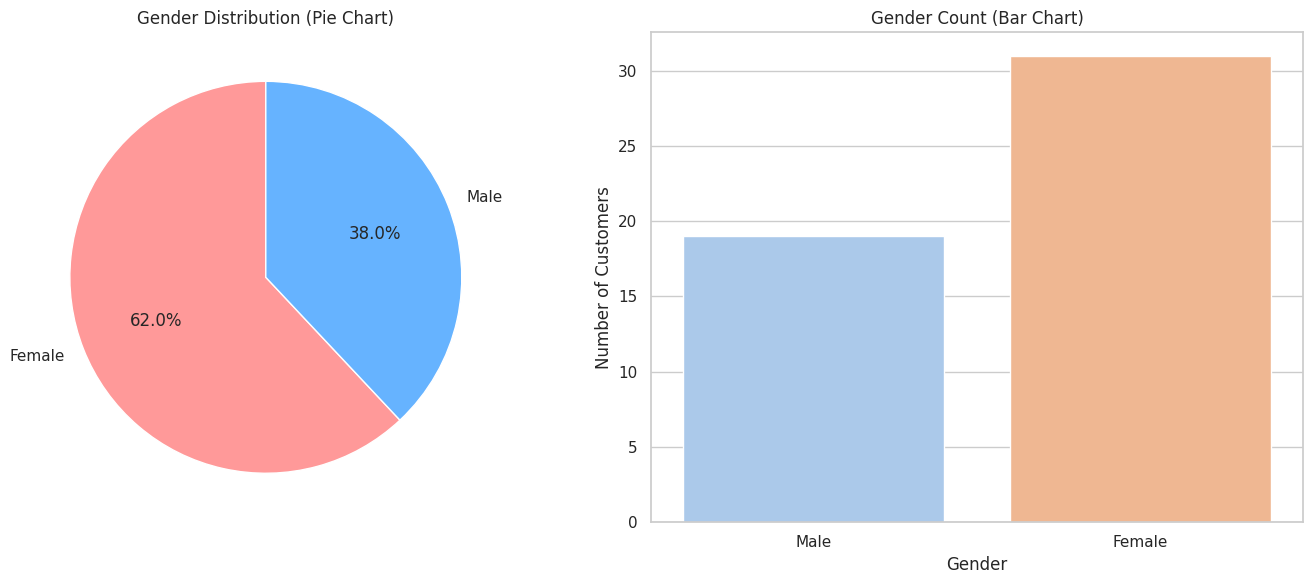

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Pie Chart (Gender Distribution)
gender_counts = df_mall['Gender'].value_counts()
axes[0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
axes[0].set_title('Gender Distribution (Pie Chart)')

# Plot 2: Bar Plot (Gender Counts)
sns.countplot(data=df_mall, x='Gender', ax=axes[1], palette='pastel')
axes[1].set_title('Gender Count (Bar Chart)')
axes[1].set_ylabel('Number of Customers')

plt.tight_layout()
plt.show()

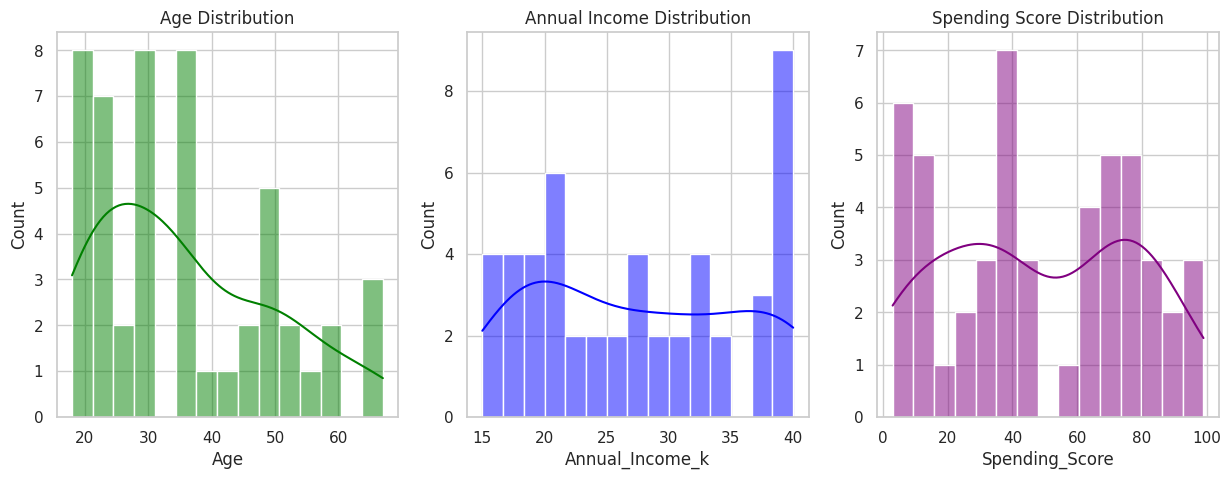

In [6]:
plt.figure(figsize=(15, 5))

# Subplot 1: Age Distribution
plt.subplot(1, 3, 1)
sns.histplot(df_mall['Age'], bins=15, kde=True, color='green')
plt.title('Age Distribution')

# Subplot 2: Income Distribution
plt.subplot(1, 3, 2)
sns.histplot(df_mall['Annual_Income_k'], bins=15, kde=True, color='blue')
plt.title('Annual Income Distribution')

# Subplot 3: Spending Score Distribution
plt.subplot(1, 3, 3)
sns.histplot(df_mall['Spending_Score'], bins=15, kde=True, color='purple')
plt.title('Spending Score Distribution')

plt.show()

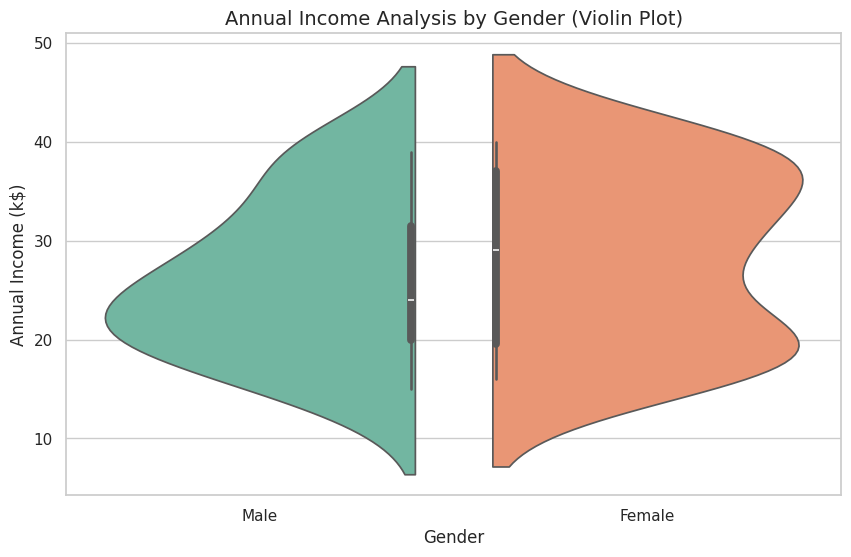

In [7]:
plt.figure(figsize=(10, 6))

# Violin Plot: Income by Gender
sns.violinplot(data=df_mall, x='Gender', y='Annual_Income_k', palette='Set2', split=True)

plt.title('Annual Income Analysis by Gender (Violin Plot)', fontsize=14)
plt.ylabel('Annual Income (k$)')
plt.show()

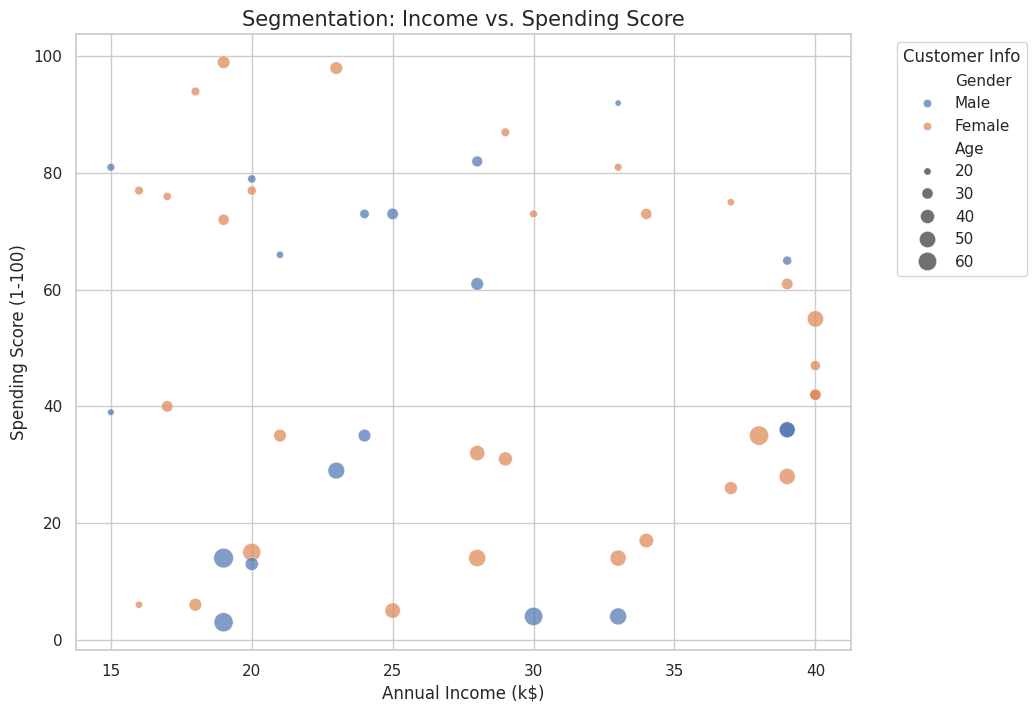

In [8]:
plt.figure(figsize=(10, 8))

# Scatter Plot with 3 variables: Income, Spending, and Age (size)
sns.scatterplot(data=df_mall,
                x='Annual_Income_k',
                y='Spending_Score',
                hue='Gender',
                size='Age',
                sizes=(20, 200),
                alpha=0.7,
                palette='deep')

plt.title('Segmentation: Income vs. Spending Score', fontsize=15)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Customer Info')
plt.show()

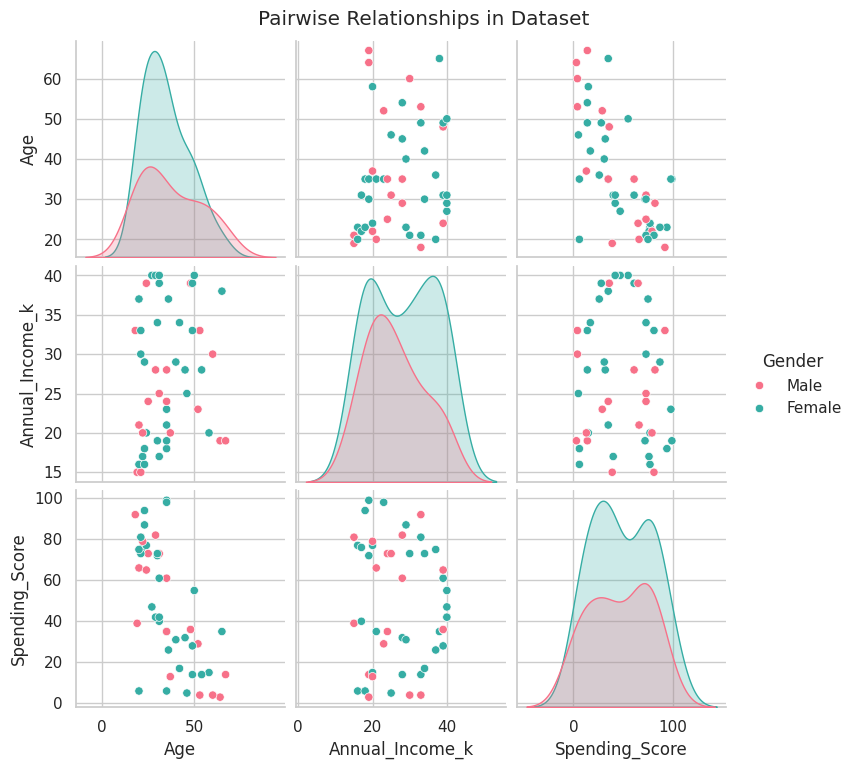

In [9]:
# Pairplot gives a comprehensive overview of all numerical relationships
sns.pairplot(df_mall.drop('CustomerID', axis=1), hue='Gender', palette='husl')
plt.suptitle('Pairwise Relationships in Dataset', y=1.02)
plt.show()

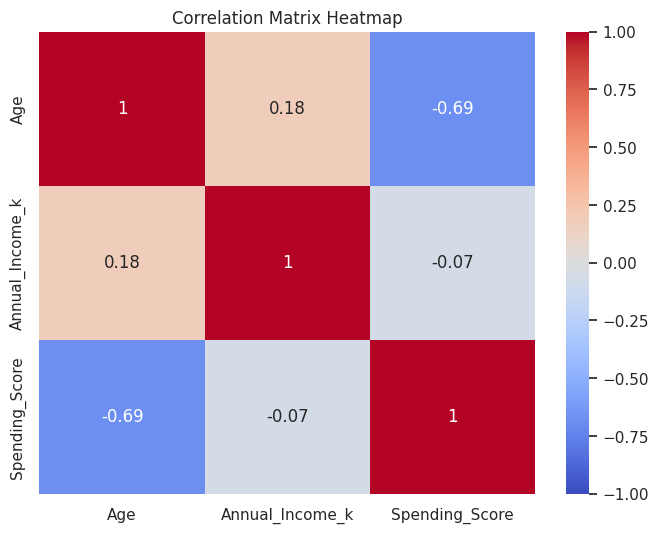

In [10]:
plt.figure(figsize=(8, 6))

# Calculate correlation for numerical columns only
corr_matrix = df_mall[['Age', 'Annual_Income_k', 'Spending_Score']].corr()

# Heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix Heatmap')
plt.show()

In [11]:
import plotly.express as px

# 3D Interactive Scatter Plot
fig = px.scatter_3d(df_mall,
                    x='Annual_Income_k',
                    y='Spending_Score',
                    z='Age',
                    color='Gender',
                    opacity=0.8,
                    title='3D Customer Segmentation',
                    template='plotly_white')

fig.update_layout(scene = dict(
                    xaxis_title='Annual Income (k$)',
                    yaxis_title='Spending Score',
                    zaxis_title='Age'))
fig.show()